# Machine learning clásico que decide de verdad

**Facsímil 1 · Los cimientos** — capítulo 11 (machine learning clásico) y capítulo 2 (determinista
frente a probabilístico).

En la era de los LLM gigantes es fácil olvidar que **la mayoría de los problemas reales de empresa
se resuelven con modelos clásicos**: rápidos, baratos, que caben en un portátil y —ventaja enorme—
que se pueden *abrir y entender*. Saber cuándo basta con lo clásico, en vez de disparar un cañón a
una mosca, es una de las señales de criterio que persigue este facsímil. En este cuaderno construyes
uno de principio a fin: un clasificador que lee mensajes de una bandeja de soporte y decide si cada
uno es una **incidencia** (algo roto, hay que actuar) o una **consulta** (una duda que puede
esperar).

### Qué vas a aprender
- El **pipeline clásico** de texto: convertir palabras en números (TF-IDF) y clasificar con
  regresión logística.
- A leer una **matriz de confusión** —no solo cuánto acierta el modelo, sino *cómo* se equivoca— y
  por qué eso importa más que el «porcentaje de acierto».
- Que **no todos los errores cuestan lo mismo**, y cómo mover el **umbral** de decisión en
  consecuencia.
- A **abrir el modelo** y ver qué palabras delatan cada clase (interpretabilidad), algo que una red
  neuronal no te regala.
- Cuántos datos hacen falta, comparando contra una línea base honesta.

### Cuánto cuesta
Unos 12 minutos. Corre en CPU; sin GPU ni claves.


> **Inteligencia artificial para gente curiosa** · facsímil interactivo
> 
> Web del facsímil: https://www.iaparagentecuriosa.686f6c61.dev/ · Autor: @686f6c61 · Fecha: 2026-06-26 · Versión 1.0
> 
> Este cuaderno acompaña al facsímil: ejecútalo de arriba abajo, lee cada celda de texto
> antes de correr la de código y detente en las salidas. La gracia no es que «salga», sino
> entender *por qué* sale.

In [1]:
# En Colab ya está todo. En tu máquina:  pip install scikit-learn numpy matplotlib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

np.random.seed(0)
print("Listo.")


Listo.


## 1. El pipeline clásico, en tres piezas

Un clasificador de texto clásico es una cadena de montaje con tres estaciones:

1. **Vectorizar:** un modelo no lee palabras, lee números (es el capítulo 9, en pequeño). Hay que
   convertir cada mensaje en un vector. Usaremos **TF-IDF**.
2. **Clasificar:** un modelo que, dado ese vector, devuelve una **probabilidad** de cada clase.
   Usaremos **regresión logística**, el caballo de batalla de la estadística aplicada.
3. **Decidir:** convertir esa probabilidad en una acción con un **umbral**.

**TF-IDF** (frecuencia de término × frecuencia inversa de documento) cuenta cuántas veces aparece
cada palabra en un mensaje (TF), pero **rebaja** el peso de las palabras que salen en todos los
mensajes —«de», «la», «que»— y **realza** las distintivas —«error», «descuento»— mediante el factor
IDF. La intuición: una palabra que aparece en *todos* los documentos no distingue nada; una que solo
aparece en algunos es informativa. El resultado es un vector por mensaje donde pesan las palabras que
de verdad importan.


## 2. El caso: una bandeja de soporte

Estos son mensajes del tipo que llega a cualquier soporte. La etiqueta es la decisión que tomaría una
persona con experiencia: `1` = incidencia (actuar ya), `0` = consulta (puede esperar). Hemos metido a
propósito algunos mensajes **ambiguos** —incidencias redactadas con tono de consulta— para que el
problema no sea trivial y se parezca a la realidad.


In [2]:
incidencias = [
    "La aplicación se cae cada vez que intento entrar, no puedo trabajar",
    "El pago me da error y ya lo he intentado tres veces",
    "No me llega el correo de confirmación y el pedido está parado",
    "La web carga en blanco desde esta mañana, urgente",
    "Me ha cobrado dos veces la misma factura, necesito que lo arregléis",
    "El botón de descargar no hace nada, está roto",
    "Llevo media hora y la página no responde, esto no va",
    "Error 500 al guardar, pierdo todo el formulario",
    "No puedo iniciar sesión, dice que mi contraseña es incorrecta y sí es correcta",
    "La factura sale con el importe equivocado, está mal calculado",
    "Se ha borrado mi pedido sin que yo hiciera nada",
    "La sincronización falla y los datos no se actualizan",
    "Me aparece la pantalla congelada y no avanza",
    "El sistema rechaza mi tarjeta válida una y otra vez",
    "Desde la última actualización la app va lentísima y se bloquea",
    "No carga ninguna imagen del catálogo, todo roto",
    "El enlace de recuperar contraseña está caído",
    "Mi cuenta aparece suspendida sin motivo y no puedo acceder",
    "La exportación a PDF da error y la necesito para hoy",
    "Se cierra solo el programa cada dos por tres",
    "El carrito pierde los productos al pasar a pagar",
    "No funciona el buscador, devuelve siempre vacío",
    "Quería comentar que llevo dos días sin recibir el pedido que ya pagué",
    "Buenas, creo que la última factura está mal, me habéis cobrado de más",
    "Hola, no sé si es normal, pero la aplicación se cierra sola a veces",
    "Me gustaría saber por qué mi cuenta aparece bloqueada desde ayer",
    "Perdón que insista, sigo sin poder acceder a mi pedido",
    "Una duda, ¿por qué me ha llegado el artículo equivocado?",
]
consultas = [
    "Hola, ¿cómo puedo cambiar mi dirección de envío?",
    "¿Tenéis descuentos para estudiantes?",
    "Quería saber si hacéis envíos a Canarias",
    "¿Cuánto tarda en llegar un pedido normalmente?",
    "Me gustaría saber cómo darme de baja de la newsletter",
    "¿Es posible pagar a plazos?",
    "Buenas, ¿dónde veo el histórico de mis facturas?",
    "¿Puedo cambiar el color después de comprar?",
    "¿Qué métodos de pago aceptáis?",
    "Quería preguntar si el producto viene con garantía",
    "¿Cómo añado un segundo usuario a mi cuenta?",
    "¿Tenéis tienda física o solo online?",
    "Me preguntaba si se puede regalar una suscripción",
    "¿Cada cuánto actualizáis el catálogo?",
    "¿Puedo recuperar una factura de hace dos años?",
    "¿Hay opción de factura para empresa con CIF?",
    "Quería saber el horario de atención al cliente",
    "¿Se puede programar el envío para una fecha concreta?",
    "¿Ofrecéis prueba gratuita antes de pagar?",
    "¿Cómo cambio el idioma de la interfaz?",
    "Buenas, ¿el precio incluye el IVA?",
    "¿Puedo tener varias direcciones guardadas?",
    "¿Puedo cambiar la fecha de entrega una vez hecho el pedido?",
    "¿Cómo funciona la devolución si el producto no me convence?",
    "Quería saber si tenéis aplicación para el móvil",
    "¿El envío es gratis a partir de cierta cantidad?",
    "¿Puedo añadir una nota de regalo al pedido?",
    "¿Tenéis atención al cliente los fines de semana?",
]
textos = incidencias + consultas
y = np.array([1]*len(incidencias) + [0]*len(consultas))
print(f"{len(incidencias)} incidencias + {len(consultas)} consultas = {len(textos)} mensajes")


28 incidencias + 28 consultas = 56 mensajes


## 3. De texto a números: TF-IDF en acción

Ajustamos el vectorizador **solo con el train** (importante: el vocabulario y los pesos IDF se
aprenden de los datos de entrenamiento, nunca del test; si no, habría fuga de información). Luego
miramos qué palabras considera más distintivas, para que TF-IDF deje de ser una sigla.


In [3]:
X_tr_txt, X_te_txt, y_tr, y_te = train_test_split(
    textos, y, test_size=0.3, random_state=1, stratify=y)

vec = TfidfVectorizer()
X_tr = vec.fit_transform(X_tr_txt)   # aprende vocabulario y pesos IDF SOLO con el train
X_te = vec.transform(X_te_txt)       # aplica lo aprendido al test
print("Vocabulario aprendido:", len(vec.vocabulary_), "palabras distintas")
print("Cada mensaje es ahora un vector de esa longitud.\n")

# las palabras con MAYOR peso IDF (las mas distintivas) y menor (las mas comunes)
idf = vec.idf_; nombres = np.array(vec.get_feature_names_out())
print("Palabras mas distintivas (IDF alto):", ", ".join(nombres[np.argsort(idf)[-8:]]))
print("Palabras mas comunes (IDF bajo):    ", ", ".join(nombres[np.argsort(idf)[:8]]))


Vocabulario aprendido: 189 palabras distintas
Cada mensaje es ahora un vector de esa longitud.

Palabras mas distintivas (IDF alto): varias, veces, usuario, veo, vez, web, yo, última
Palabras mas comunes (IDF bajo):     el, de, la, no, pedido, me, puedo, una


## 4. Entrenar y mirar a la cara los aciertos... y los fallos

Entrenamos la **regresión logística**. Devuelve una **probabilidad** de que el mensaje sea
incidencia. Para evaluarla no nos basta el «porcentaje de acierto»: usamos la **matriz de
confusión**, que cruza lo real con lo predicho en cuatro casillas:

|  | predijo incidencia | predijo consulta |
|---|---|---|
| **era incidencia** | acierto (VP) | **fallo caro** (FN) |
| **era consulta** | fallo barato (FP) | acierto (VN) |

La casilla que de verdad duele es la de arriba a la derecha: una **incidencia tratada como consulta**
(un falso negativo). En una empresa, eso es un sistema roto que nadie atiende.


In [4]:
clf = LogisticRegression(max_iter=1000)
clf.fit(X_tr, y_tr)
pred = clf.predict(X_te)

cm = confusion_matrix(y_te, pred, labels=[1, 0])
print("Matriz de confusión (filas = realidad, columnas = predicción):")
print("                 pred:INCID   pred:CONSULTA")
print(f"  real INCIDENCIA     {cm[0,0]:>3}          {cm[0,1]:>3}   <- la casilla cara")
print(f"  real CONSULTA       {cm[1,0]:>3}          {cm[1,1]:>3}")
print()
print(classification_report(y_te, pred, target_names=["consulta", "incidencia"]))


Matriz de confusión (filas = realidad, columnas = predicción):
                 pred:INCID   pred:CONSULTA
  real INCIDENCIA       8            1   <- la casilla cara
  real CONSULTA         1            7

              precision    recall  f1-score   support

    consulta       0.88      0.88      0.88         8
  incidencia       0.89      0.89      0.89         9

    accuracy                           0.88        17
   macro avg       0.88      0.88      0.88        17
weighted avg       0.88      0.88      0.88        17



## 5. Qué significan precisión, recall y F1

El informe de arriba trae tres números por clase. Conviene entenderlos, porque resumen *cómo* falla
el modelo:

- **Precisión** = de todo lo que el modelo marcó como incidencia, ¿qué fracción lo era de verdad?
  (Mide cuánto te puedes fiar de una alarma.) $\text{precisión} = \frac{VP}{VP+FP}$
- **Recall** (sensibilidad) = de todas las incidencias reales, ¿cuántas cazó? (Mide cuántas se te
  escapan.) $\text{recall} = \frac{VP}{VP+FN}$
- **F1** = media armónica de las dos, un único número de compromiso. $F1 = 2\cdot\frac{P\cdot R}{P+R}$

Casi siempre hay tensión entre precisión y recall: cazar *todas* las incidencias (recall alto) suele
implicar más falsas alarmas (precisión baja), y viceversa. El **umbral** es la palanca que regula ese
equilibrio.


## 6. Mover el umbral según lo que cuesta equivocarse

Por defecto el modelo dice «incidencia» si la probabilidad supera 0.5. Pero 0.5 no tiene nada de
sagrado: es solo el centro de la escala. Si perder una incidencia es mucho peor que molestar con una
consulta, podemos **bajar el listón** para atrapar más incidencias, a cambio de algún falso positivo
barato. Recorremos los umbrales y miramos los dos tipos de error en cada uno.


In [5]:
proba = clf.predict_proba(X_te)[:, 1]   # probabilidad de "incidencia"
print("umbral | incidencias que se escapan (caro) | consultas molestadas (barato)")
for umbral in [0.5, 0.35, 0.2]:
    pred_u = (proba >= umbral).astype(int)
    cm = confusion_matrix(y_te, pred_u, labels=[1, 0])
    print(f"  {umbral:>4}  |              {cm[0,1]:>2}                   |          {cm[1,0]:>2}")
print("\nAl bajar el umbral atrapas la incidencia que se escapaba, pero molestas a mas consultas.")
print("No hay un valor 'correcto': depende de cuanto cuesta cada error. Es decision de negocio.")


umbral | incidencias que se escapan (caro) | consultas molestadas (barato)
   0.5  |               1                   |           1
  0.35  |               0                   |           7
   0.2  |               0                   |           8

Al bajar el umbral atrapas la incidencia que se escapaba, pero molestas a mas consultas.
No hay un valor 'correcto': depende de cuanto cuesta cada error. Es decision de negocio.


## 7. Abrir el modelo: ¿qué palabras delatan a una incidencia?

Un clasificador clásico tiene una ventaja enorme sobre una red neuronal: **se puede leer por
dentro**. Sus coeficientes nos dicen qué palabras empujan hacia «incidencia» y cuáles hacia
«consulta». Esto es *interpretabilidad* de verdad, no aproximada: el modelo es transparente.


In [6]:
pesos = clf.coef_[0]
top_incid = nombres[np.argsort(pesos)[-10:]][::-1]
top_consulta = nombres[np.argsort(pesos)[:10]]
print("Palabras que más gritan INCIDENCIA:", ", ".join(top_incid))
print("Palabras que más suenan a CONSULTA:", ", ".join(top_consulta))
print("\nTienen sentido: 'no', 'error', 'roto' frente a 'quería', 'puedo', 'cómo'.")


Palabras que más gritan INCIDENCIA: no, que, está, sin, se, los, contraseña, roto, todo, por
Palabras que más suenan a CONSULTA: de, cómo, puedo, saber, para, si, cuánto, una, tenéis, buenas

Tienen sentido: 'no', 'error', 'roto' frente a 'quería', 'puedo', 'cómo'.


## 8. ¿Es bueno? Comparar contra una línea base honesta

Un número de acierto no significa nada sin algo con qué compararlo. La línea base más básica: un
modelo tonto que siempre predice la clase mayoritaria. Si nuestro modelo no le gana con holgura, no
está aprendiendo gran cosa.


In [7]:
from sklearn.dummy import DummyClassifier
tonto = DummyClassifier(strategy="most_frequent").fit(X_tr, y_tr)
acc_tonto = tonto.score(X_te, y_te)
acc_modelo = clf.score(X_te, y_te)
print(f"Modelo tonto (siempre la clase mayoritaria): {acc_tonto:.3f}")
print(f"Nuestro modelo (TF-IDF + regresión):         {acc_modelo:.3f}")
print(f"Mejora sobre el tonto: +{100*(acc_modelo-acc_tonto):.0f} puntos. Eso si es aprender.")


Modelo tonto (siempre la clase mayoritaria): 0.471
Nuestro modelo (TF-IDF + regresión):         0.882
Mejora sobre el tonto: +41 puntos. Eso si es aprender.


## 9. ¿Cuántos datos hacen falta? Curva de aprendizaje

Una pregunta práctica de oro: ¿merece la pena etiquetar más mensajes? Lo medimos entrenando con cada
vez más datos y viendo cómo evoluciona el acierto. Cuando la curva se aplana, etiquetar más rinde
poco.


/home/r/.cache/uv/archive-v0/1xU16R6qkEyt5aJDaKxoR/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:489: FitFailedWarning: 
8 fits failed out of a total of 24.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
8 fits failed with the following error:
Traceback (most recent call last):
  File "/home/r/.cache/uv/archive-v0/1xU16R6qkEyt5aJDaKxoR/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 856, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/r/.cache/uv/archive-v0/1xU16R6qkEyt5aJDaKxoR/lib/python3.13/site-packages/sklearn/base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/h

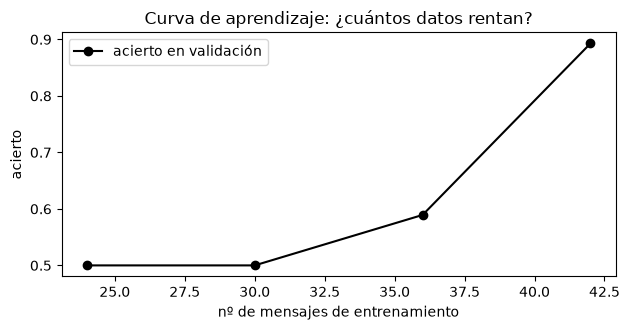

Si la curva sigue subiendo al final, mas datos ayudarian; si se aplana, ya rinde poco.


In [8]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import learning_curve
pipe = make_pipeline(TfidfVectorizer(), LogisticRegression(max_iter=1000))
tam, tr_sc, te_sc = learning_curve(pipe, textos, y, cv=4,
                                   train_sizes=np.linspace(0.3, 1.0, 6))
plt.figure(figsize=(6.5, 3.4))
plt.plot(tam, te_sc.mean(1), "-o", color="black", label="acierto en validación")
plt.xlabel("nº de mensajes de entrenamiento"); plt.ylabel("acierto")
plt.title("Curva de aprendizaje: ¿cuántos datos rentan?"); plt.legend()
plt.tight_layout(); plt.show()
print("Si la curva sigue subiendo al final, mas datos ayudarian; si se aplana, ya rinde poco.")


## 10. Pruébalo tú

1. **Escribe tu propio mensaje** y pásalo por el modelo:
   ```python
   m = ["la app no carga y tengo una reunión en cinco minutos"]
   print(clf.predict_proba(vec.transform(m))[0, 1])
   ```
   ¿Le pones tú una probabilidad parecida?
2. **Mensajes tramposos:** prueba «quería saber por qué la app se ha caído». Mezcla tono de consulta
   («quería saber») y de incidencia («se ha caído»). ¿Hacia dónde se inclina?
3. **Cambia a bigramas** (`TfidfVectorizer(ngram_range=(1,2))`): ahora «no funciona» cuenta como una
   unidad. ¿Mejora? Más contexto a veces ayuda.
4. **Pondera las clases** (`class_weight='balanced'`): si te importa más no perder incidencias, dile
   al modelo que pesen más. ¿Cómo cambia la matriz de confusión?


## 11. Errores comunes

- **Confundir acierto con utilidad.** Si el 90% de los mensajes fueran consultas, un modelo que diga
  «siempre consulta» acertaría el 90% y sería inservible. Por eso comparamos contra el tonto.
- **Ajustar el vectorizador con todo el dataset** (train + test) antes de partir: fuga de información,
  resultados optimistas y falsos. Ajusta solo con el train.
- **Quedarse con el umbral 0.5 por defecto** cuando los errores no cuestan lo mismo. Elegir umbral es
  parte del trabajo, no un detalle técnico.
- **Olvidar la interpretabilidad.** Mirar los coeficientes a menudo revela que el modelo «acierta por
  el motivo equivocado» (una palabra espuria). Mirarlos es gratis y salva disgustos.


## 12. Qué te llevas

- Un modelo **clásico** (TF-IDF + regresión logística) resuelve de sobra muchísimos problemas de
  texto, es rápido, barato y **se entiende por dentro**. Saber cuándo basta con esto es criterio.
- La **matriz de confusión** importa más que el «porcentaje de acierto»: te dice *cómo* fallas, y casi
  siempre un tipo de error cuesta más que el otro.
- **Precisión, recall y F1** ponen número a ese «cómo»; el **umbral** es la palanca para moverlo, y
  0.5 es solo un punto de partida.
- Comparar contra una **línea base** y mirar la **curva de aprendizaje** son dos hábitos baratos que
  separan el trabajo serio de la demostración bonita.

**Para seguir en el facsímil:** el capítulo 9 cambia TF-IDF por *embeddings* (texto a vectores con
significado); el facsímil 7 entero va de evaluar y calibrar estas decisiones; y el facsímil 4 te enseña
cuándo merece la pena subir de lo clásico a un LLM... y cuándo no.


---

### Ficha del cuaderno

- **Obra:** *Inteligencia artificial para gente curiosa* (facsímil interactivo).
- **Web:** https://www.iaparagentecuriosa.686f6c61.dev/
- **Autor:** @686f6c61
- **Fecha:** 2026-06-26
- **Versión:** 1.0

*Material pedagógico. Las salidas que ves son reales: se generan al ejecutar el código, no están escritas a mano. Si cambias algo, cambiarán: esa es la idea.*